In [92]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import heapq

# 目標色の生成における各絵の具のグラム数

平均値: 0.9956232238846083
中央値: 0.6921466802263617
標準偏差: 0.9849589089219601


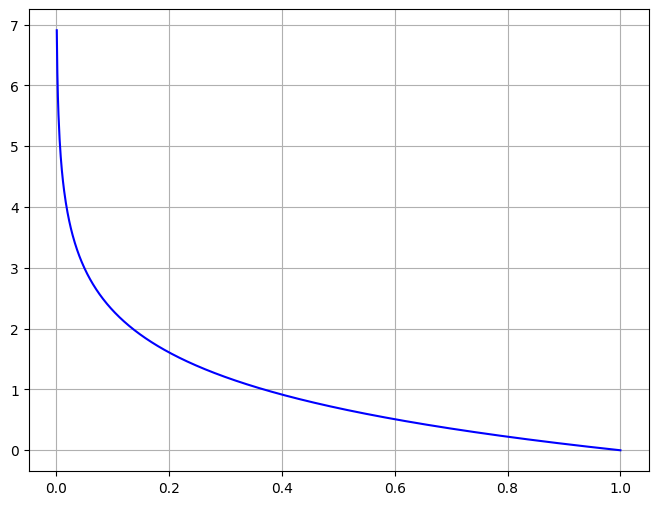

In [2]:
# 0から1までの等間隔な値を生成
samples = np.linspace(0, 1, 1000)[1:]

# 対応する -ln(rand_double(0,1)) を計算
values = -np.log(samples)
print(f'平均値: {np.mean(values)}')
print(f'中央値: {np.median(values)}')
print(f'標準偏差: {np.std(values)}')

# グラフをプロット
plt.figure(figsize=(8, 6))
plt.plot(samples, values, color="blue")
plt.grid()
plt.show()

In [3]:
n = len(values)
cnt = [0 for _ in range(n)]
for v in values[1:]:
    cnt[int(v)] += 1
for i in range(100):
    if cnt[i] == 0:
        continue
    print(f'{i+1}未満: {cnt[i]}回')

1未満: 632回
2未満: 232回
3未満: 86回
4未満: 31回
5未満: 12回
6未満: 4回
7未満: 1回


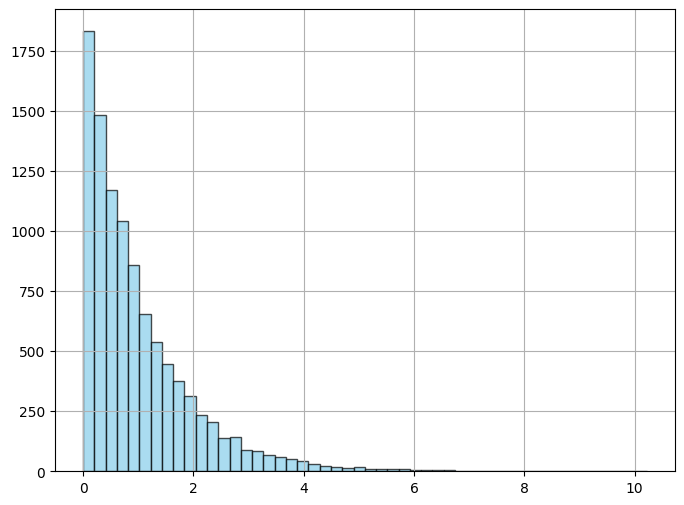

In [4]:
# サンプル数
num_samples = 10000

# モンテカルロでランダム値を生成 (1から4の範囲でランダムサンプリング)
random_samples = np.random.uniform(0, 1, num_samples)

# 対応する値を計算：10^samples
values = -np.log(random_samples)

# ヒストグラムをプロット
plt.figure(figsize=(8, 6))
plt.hist(values, bins=50, color='skyblue', alpha=0.7, edgecolor='black')
plt.grid()
plt.show()

# 絵具と目標の色との誤差

In [30]:
def load_input(filename):
    with open(filename, "r") as file:
        n, k, h, t, d = map(int, file.readline().split())
        own = []
        for _ in range(k):
            (c, m, y) = map(float, file.readline().split())
            own.append((c,m,y))
        target = []
        for _ in range(h):
            (c, m, y) = map(float, file.readline().split())
            target.append((c,m,y))
        assert n==20
        assert h==1000
        assert len(own)==k
        assert len(target)==h
        print(f'K={k}, T={t}, D={d}')
    return n, k, h, t, d, own, target

n, k, h, t, d, own, target = load_input('in/0000.txt')

K=4, T=60887, D=3822


In [45]:
def dist(cmy1, cmy2):
    c1, m1, y1 = cmy1
    c2, m2, y2 = cmy2
    e = ((c1-c2)**2 + (m1-m2)**2 + (y1-y2)**2)**(1/2)
    return e

score = 1
for i, (c2,m2,y2) in enumerate(target):
    # print(f'i: {i}', end='')
    errors = []
    for j, (c1,m1,y1) in enumerate(own):
        e = dist((c1,m1,y1), (c2,m2,y2))
        errors.append(e)
        # print(f', k{j} e: {e}', end='')
    score += min(errors)
    # print('')
score *= 10000
score = round(score)
print(f'score: {score:,}')

score: 2,319,645


In [25]:
print(f'目標の色: {target[0]}')
print(f'絵の具: {own}')
def mixing_color(cnt):
    (c1, m1, y1) = (0, 0, 0)
    s = 0
    for i, c in enumerate(cnt):
        (c2, m2, y2) = own[i]
        s += c
        c1 += c2*c
        m1 += m2*c
        y1 += y2*c
    if s != 0:
        c1 /= s
        m1 /= s
        y1 /= s
    color = (c1, m1, y1)
    return color

mixing_color([0, 0, 0, 0])
mixing_color([1, 1, 1, 1])

k2 = 30

cnt = 0
opt_trial = [0, 0, 0, 0]
opt_score = 1_000_000_000
for c1 in range(k2):
    for c2 in range(k2):
        for c3 in range(k2):
            for c4 in range(k2):
                trial = [c1, c2, c3, c4]
                cnt += 1
                color = mixing_color(trial)
                # score = 10000*dist(color, target[0]) + d*(sum(trial)-1)
                score = 10000*dist(color, target[0])
                if score < opt_score:
                    print(f'trial cnt: {cnt}, trial: {trial}, color: {color}, e: {dist(color, target[0])}, score: {round(score)}')
                    opt_score = score
                    opt_trial = trial
print(f'opt score: {opt_score}, trial: {opt_trial}, cnt: {cnt}')

目標の色: (0.61961, 0.60986, 0.43973)
絵の具: [(0.68467, 0.08841, 0.96843), (0.82163, 0.75362, 0.94401), (0.89724, 0.39773, 0.74235), (0.46826, 0.75655, 0.04192), (0.56157, 0.74651, 0.20106), (0.75955, 0.5624, 0.53667), (0.79334, 0.46125, 0.43409), (0.56927, 0.54371, 0.58359), (0.98846, 0.40105, 0.07755), (0.07564, 0.64252, 0.01799), (0.76815, 0.73496, 0.93674), (0.48322, 0.58586, 0.83992), (0.49506, 0.94045, 0.4795), (0.24431, 0.46916, 0.16513)]
trial cnt: 1, trial: [0, 0, 0, 0], color: (0.0, 0.0, 0.0), e: 0.9742731878687825, score: 9743
trial cnt: 2, trial: [0, 0, 0, 1], color: (0.46826, 0.75655, 0.04192), e: 0.4501972619863431, score: 4502
trial cnt: 4, trial: [0, 0, 0, 3], color: (0.46826000000000007, 0.75655, 0.04191999999999999), e: 0.450197261986343, score: 4502
trial cnt: 32, trial: [0, 0, 1, 1], color: (0.68275, 0.57714, 0.39213499999999996), e: 0.08557185299501233, score: 856
trial cnt: 528, trial: [0, 0, 17, 17], color: (0.68275, 0.57714, 0.392135), e: 0.0855718529950123, score: 85

# Dの分布

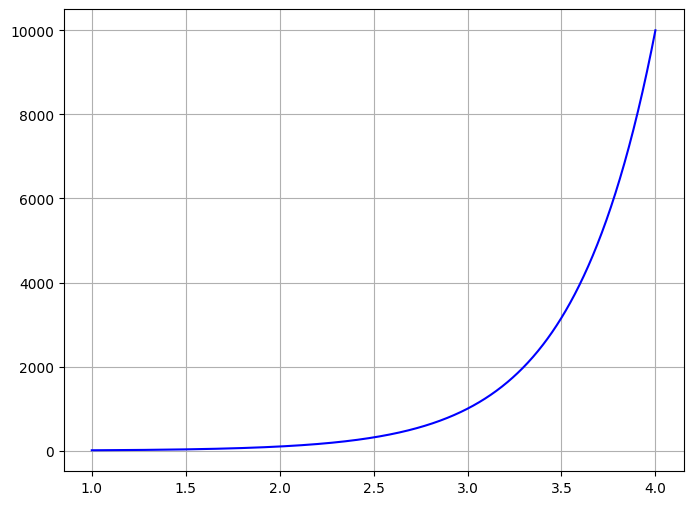

In [8]:
# 0から1までの等間隔な値を生成
samples = np.linspace(1, 4, 1000)

# 対応する -ln(rand_double(0,1)) を計算
values = 10**samples

# グラフをプロット
plt.figure(figsize=(8, 6))
plt.plot(samples, values, color="blue")
plt.grid()
plt.show()

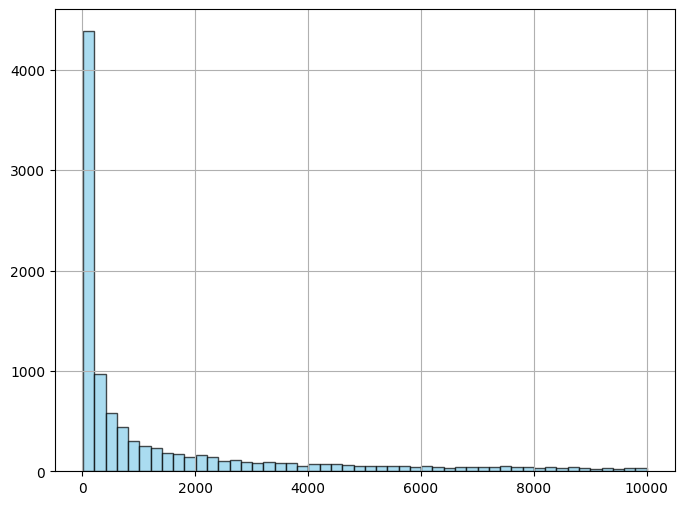

In [9]:
# サンプル数
num_samples = 10000

# モンテカルロでランダム値を生成 (1から4の範囲でランダムサンプリング)
random_samples = np.random.uniform(1, 4, num_samples)

# 対応する値を計算：10^samples
values = 10 ** random_samples

# ヒストグラムをプロット
plt.figure(figsize=(8, 6))
plt.hist(values, bins=50, color='skyblue', alpha=0.7, edgecolor='black')
plt.grid()
plt.show()

# seed=1

In [31]:
n, k, h, t, d, own, target = load_input('in/0001.txt')

score = 1
for i, (c2,m2,y2) in enumerate(target):
    # print(f'i: {i}', end='')
    errors = []
    for j, (c1,m1,y1) in enumerate(own):
        e = dist((c1,m1,y1), (c2,m2,y2))
        errors.append(e)
        # print(f', k{j} e: {e}', end='')
    score += min(errors)
    # print('')
score *= 10000
score = round(score)
print(f'score: {score:,}')

cnt = 0
opt_trial = [0, 0, 0, 0]
opt_score = 1_000_000_000
for c1 in range(k):
    for c2 in range(k):
        for c3 in range(k):
            for c4 in range(k):
                trial = [c1, c2, c3, c4]
                cnt += 1
                color = mixing_color(trial)
                score = 10000*dist(color, target[0]) + d*(sum(trial)-1)
                if score < opt_score:
                    print(f'trial cnt: {cnt}, trial: {trial}, color: {color}, e: {dist(color, target[0])}, score: {round(score)}')
                    opt_score = score
                    opt_trial = trial
print(f'opt score: {opt_score}, trial: {opt_trial}, cnt: {cnt}')

K=9, T=23052, D=13
score: 2,220,598
trial cnt: 1, trial: [0, 0, 0, 0], color: (0.0, 0.0, 0.0), e: 0.8746329514716445, score: 8733
trial cnt: 2, trial: [0, 0, 0, 1], color: (0.07822, 0.81449, 0.27609), e: 0.7284754476301861, score: 7285
trial cnt: 10, trial: [0, 0, 1, 0], color: (0.29789, 0.20344, 0.44055), e: 0.34489363432803455, score: 3449
trial cnt: 83, trial: [0, 1, 0, 1], color: (0.50061, 0.49819500000000005, 0.265635), e: 0.3140574591535759, score: 3154
trial cnt: 91, trial: [0, 1, 1, 0], color: (0.610445, 0.19267, 0.347865), e: 0.25482871551298925, score: 2561
trial cnt: 100, trial: [0, 1, 2, 0], color: (0.50626, 0.19626000000000002, 0.37876), e: 0.2435128657792027, score: 2461
trial cnt: 173, trial: [0, 2, 1, 1], color: (0.5555275, 0.34543250000000003, 0.30675), e: 0.23182347705204492, score: 2357
trial cnt: 182, trial: [0, 2, 2, 1], color: (0.504, 0.31703400000000004, 0.33351), e: 0.2237708666828638, score: 2290
trial cnt: 272, trial: [0, 3, 3, 1], color: (0.5344128571428571, 

# 3つの絵の具で目標の色を作成

In [11]:
(c, m, y) = target[0]
(c1, m1, y1) = own[0]
(c2, m2, y2) = own[1]
(c3, m3, y3) = own[2]

def coefficient(cmy, cmy1, cmy2, cmy3):
    (c, m, y) = cmy
    (c1, m1, y1) = cmy1
    (c2, m2, y2) = cmy2
    (c3, m3, y3) = cmy3
    
    # 行列の決定因子(デターミナント)を計算
    det = (
        c1 * (m2 * y3 - y2 * m3)
        - m1 * (c2 * y3 - y2 * c3)
        + y1 * (c2 * m3 - m2 * c3)
    )

    if det == 0:
        (0, 0, 0)

    # 係数を計算
    a1 = (
        c * (m2 * y3 - y2 * m3)
        - m * (c2 * y3 - y2 * c3)
        + y * (c2 * m3 - m2 * c3)
    ) / det

    a2 = (
        c1 * (m * y3 - y * m3)
        - m1 * (c * y3 - y * c3)
        + y1 * (c * m3 - m * c3)
    ) / det

    a3 = (
        c1 * (m2 * y - y2 * m)
        - m1 * (c2 * y - y2 * c)
        + y1 * (c2 * m - m2 * c)
    ) / det
    
    return (a1, a2, a3)

coefficient((c, m, y), (c1, m1, y1), (c2, m2, y2), (c3, m3, y3))

(0.8911469030880155, 0.2824435123558617, -0.5361482317658894)

# 2つの絵の具で目標の色を作成

In [12]:
(c, m, y) = target[0]
print(f'target: {target[0]}')

primes = [2, 3, 5]
opt_i1 = 0
opt_i2 = 0
opt_p = 0
opt_i = 0
opt_e = dist((c,m,y), own[0])


for i1 in range(k):
    (c1, m1, y1) = own[i1]
    e = dist((c,m,y), (c1,m1,y1))  # 1つだけ
    if opt_e > e:
        print(f'update {opt_e} => {e}, i1: {i1}, cmy: {(cc,mm,yy)}')
        opt_i1 = i1
        opt_e = e
    for i2 in range(k):
        (c2, m2, y2) = own[i2]
        cc = (c1 + c2) / 2
        mm = (m1 + m2) / 2
        yy = (y1 + y2) / 2
        e = dist((c,m,y), (cc,mm,yy))
        if opt_e > e:
            print(f'update {opt_e} => {e}, i1: {i1}, i2: {i2}, cmy: {(cc,mm,yy)}')
            opt_i1 = i1
            opt_i2 = i2
            opt_p = 1
            opt_i = 1
            opt_e = e
        for p in primes:
            for i in range(1, p):
                cc = (c1*i + c2*p) / (i+p)
                mm = (m1*i + m2*p) / (i+p)
                yy = (y1*i + y2*p) / (i+p)
                e = dist((c,m,y), (cc,mm,yy))
                if opt_e > e:
                    print(f'update {opt_e} => {e}, i1: {i1}, i2: {i2}, p: {p}, i: {i}, cmy: {(cc,mm,yy)}')
                    opt_i1 = i1
                    opt_i2 = i2
                    opt_p = 1
                    opt_i = 1
                    opt_e = e


target: (0.58819, 0.36361, 0.53554)
update 0.27555550185035316 => 0.15187054602522512, i1: 0, i2: 1, cmy: (0.7348600000000001, 0.32733500000000004, 0.520155)
update 0.15187054602522512 => 0.1505725642339932, i1: 0, i2: 5, cmy: (0.71638, 0.43834, 0.50995)
update 0.1505725642339932 => 0.1118833625800648, i1: 1, i2: 0, p: 2, i: 1, cmy: (0.6721466666666668, 0.37581333333333333, 0.60848)
update 0.1118833625800648 => 0.1118648858696285, i1: 1, i2: 0, p: 5, i: 3, cmy: (0.687825, 0.36369375000000004, 0.5863987500000001)
update 0.1118648858696285 => 0.10030912894647226, i1: 7, i2: 8, cmy: (0.540805, 0.32914000000000004, 0.616955)
update 0.10030912894647226 => 0.07296245625129566, i1: 7, i2: 8, p: 2, i: 1, cmy: (0.63882, 0.41597333333333336, 0.5398066666666667)
update 0.07296245625129566 => 0.040928725267225255, i1: 7, i2: 8, p: 3, i: 2, cmy: (0.5996140000000001, 0.38124, 0.570666)


## seed=0

In [32]:
n, k, h, t, d, own, target = load_input('in/0000.txt')

score = 1
for i, (c2,m2,y2) in enumerate(target):
    # print(f'i: {i}', end='')
    errors = []
    for j, (c1,m1,y1) in enumerate(own):
        e = dist((c1,m1,y1), (c2,m2,y2))
        errors.append(e)
        # print(f', k{j} e: {e}', end='')
    score += min(errors)
    # print('')
score *= 10000
score = round(score)
print(f'1つのみscore: {score:,}')


primes = [2, 3, 5]
score = 1

for (c,m,y) in tqdm(target):
    # print(f'target: {(c,m,y)}')
    opt_i1 = 0
    opt_i2 = 0
    opt_p = 0
    opt_i = 0
    opt_e = dist((c,m,y), own[0])
    opt_s = opt_e*10000
    for i1 in range(k):
        (c1, m1, y1) = own[i1]
        e = dist((c,m,y), (c1,m1,y1))  # 1つだけ
        s = e*10000
        if opt_s > s:
            # print(f'update {opt_e} => {e}, i1: {i1}, cmy: {(cc,mm,yy)}')
            opt_i1 = i1
            opt_e = e
            opt_s = s
        for i2 in range(k):
            (c2, m2, y2) = own[i2]
            cc = (c1 + c2) / 2
            mm = (m1 + m2) / 2
            yy = (y1 + y2) / 2
            e = dist((c,m,y), (cc,mm,yy))
            s = e*10000+d
            if opt_s > s:
                # print(f'update {opt_e} => {e}, i1: {i1}, i2: {i2}, cmy: {(cc,mm,yy)}')
                opt_i1 = i1
                opt_i2 = i2
                opt_p = 1
                opt_i = 1
                opt_e = e
                opt_s = s
            for p in primes:
                for i in range(1, p):
                    cc = (c1*i + c2*p) / (i+p)
                    mm = (m1*i + m2*p) / (i+p)
                    yy = (y1*i + y2*p) / (i+p)
                    e = dist((c,m,y), (cc,mm,yy))
                    s = e*10000+d
                    if opt_s > s:
                        # print(f'update {opt_e} => {e}, i1: {i1}, i2: {i2}, p: {p}, i: {i}, cmy: {(cc,mm,yy)}')
                        opt_i1 = i1
                        opt_i2 = i2
                        opt_p = 1
                        opt_i = 1
                        opt_e = e
                        opt_s = s
    score += opt_s

print(f'2つ使うscore: {round(score):,}')

K=4, T=60887, D=3822
1つのみscore: 2,319,645


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 7857.59it/s]

2つ使うscore: 2,309,565


# seed=1

In [33]:
n, k, h, t, d, own, target = load_input('in/0001.txt')

score = 1
for i, (c2,m2,y2) in enumerate(target):
    # print(f'i: {i}', end='')
    errors = []
    for j, (c1,m1,y1) in enumerate(own):
        e = dist((c1,m1,y1), (c2,m2,y2))
        errors.append(e)
        # print(f', k{j} e: {e}', end='')
    score += min(errors)
    # print('')
score *= 10000
score = round(score)
print(f'1つのみscore: {score:,}')


primes = [2, 3, 5]
score = 1

for (c,m,y) in tqdm(target):
    # print(f'target: {(c,m,y)}')
    opt_i1 = 0
    opt_i2 = 0
    opt_p = 0
    opt_i = 0
    opt_e = dist((c,m,y), own[0])
    opt_s = opt_e*10000
    for i1 in range(k):
        (c1, m1, y1) = own[i1]
        e = dist((c,m,y), (c1,m1,y1))  # 1つだけ
        s = e*10000
        if opt_s > s:
            # print(f'update {opt_e} => {e}, i1: {i1}, cmy: {(cc,mm,yy)}')
            opt_i1 = i1
            opt_e = e
            opt_s = s
        for i2 in range(k):
            (c2, m2, y2) = own[i2]
            cc = (c1 + c2) / 2
            mm = (m1 + m2) / 2
            yy = (y1 + y2) / 2
            e = dist((c,m,y), (cc,mm,yy))
            s = e*10000+d
            if opt_s > s:
                # print(f'update {opt_e} => {e}, i1: {i1}, i2: {i2}, cmy: {(cc,mm,yy)}')
                opt_i1 = i1
                opt_i2 = i2
                opt_p = 1
                opt_i = 1
                opt_e = e
                opt_s = s
            for p in primes:
                for i in range(1, p):
                    cc = (c1*i + c2*p) / (i+p)
                    mm = (m1*i + m2*p) / (i+p)
                    yy = (y1*i + y2*p) / (i+p)
                    e = dist((c,m,y), (cc,mm,yy))
                    s = e*10000+d
                    if opt_s > s:
                        # print(f'update {opt_e} => {e}, i1: {i1}, i2: {i2}, p: {p}, i: {i}, cmy: {(cc,mm,yy)}')
                        opt_i1 = i1
                        opt_i2 = i2
                        opt_p = 1
                        opt_i = 1
                        opt_e = e
                        opt_s = s
    score += opt_s

print(f'2つ使うscore: {round(score):,}')

K=9, T=23052, D=13
1つのみscore: 2,220,598


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1483.86it/s]

2つ使うscore: 525,320


In [34]:
n, k, h, t, d, own, target = load_input('in/0002.txt')

score = 1
for i, (c2,m2,y2) in enumerate(target):
    # print(f'i: {i}', end='')
    errors = []
    for j, (c1,m1,y1) in enumerate(own):
        e = dist((c1,m1,y1), (c2,m2,y2))
        errors.append(e)
        # print(f', k{j} e: {e}', end='')
    score += min(errors)
    # print('')
score *= 10000
score = round(score)
print(f'1つのみscore: {score:,}')


primes = [2, 3, 5]
score = 1

for (c,m,y) in tqdm(target):
    # print(f'target: {(c,m,y)}')
    opt_i1 = 0
    opt_i2 = 0
    opt_p = 0
    opt_i = 0
    opt_e = dist((c,m,y), own[0])
    opt_s = opt_e*10000
    for i1 in range(k):
        (c1, m1, y1) = own[i1]
        e = dist((c,m,y), (c1,m1,y1))  # 1つだけ
        s = e*10000
        if opt_s > s:
            # print(f'update {opt_e} => {e}, i1: {i1}, cmy: {(cc,mm,yy)}')
            opt_i1 = i1
            opt_e = e
            opt_s = s
        for i2 in range(k):
            (c2, m2, y2) = own[i2]
            cc = (c1 + c2) / 2
            mm = (m1 + m2) / 2
            yy = (y1 + y2) / 2
            e = dist((c,m,y), (cc,mm,yy))
            s = e*10000+d
            if opt_s > s:
                # print(f'update {opt_e} => {e}, i1: {i1}, i2: {i2}, cmy: {(cc,mm,yy)}')
                opt_i1 = i1
                opt_i2 = i2
                opt_p = 1
                opt_i = 1
                opt_e = e
                opt_s = s
            for p in primes:
                for i in range(1, p):
                    cc = (c1*i + c2*p) / (i+p)
                    mm = (m1*i + m2*p) / (i+p)
                    yy = (y1*i + y2*p) / (i+p)
                    e = dist((c,m,y), (cc,mm,yy))
                    s = e*10000+d
                    if opt_s > s:
                        # print(f'update {opt_e} => {e}, i1: {i1}, i2: {i2}, p: {p}, i: {i}, cmy: {(cc,mm,yy)}')
                        opt_i1 = i1
                        opt_i2 = i2
                        opt_p = 1
                        opt_i = 1
                        opt_e = e
                        opt_s = s
    score += opt_s

print(f'2つ使うscore: {round(score):,}')

K=5, T=9827, D=1392
1つのみscore: 3,146,752


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 4883.54it/s]

2つ使うscore: 2,261,537


K=14, T=4349, D=14
1つのみscore: 1,290,661


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:01<00:00, 601.22it/s]


2つ使うscore: 337,304


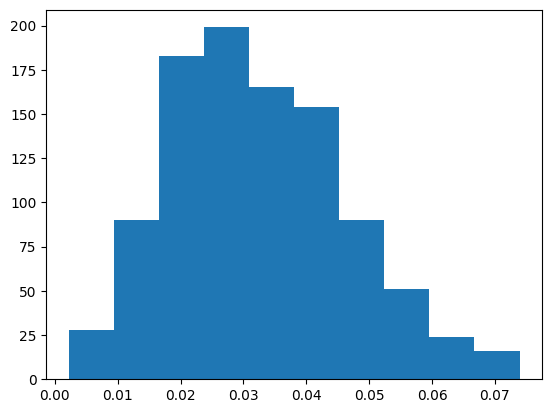

In [35]:
n, k, h, t, d, own, target = load_input('in/0003.txt')

score = 1
for i, (c2,m2,y2) in enumerate(target):
    # print(f'i: {i}', end='')
    errors = []
    for j, (c1,m1,y1) in enumerate(own):
        e = dist((c1,m1,y1), (c2,m2,y2))
        errors.append(e)
        # print(f', k{j} e: {e}', end='')
    score += min(errors)
    # print('')
score *= 10000
score = round(score)
print(f'1つのみscore: {score:,}')


primes = [2, 3, 5]
score = 1
errors = []

for (c,m,y) in tqdm(target):
    # print(f'target: {(c,m,y)}')
    opt_i1 = 0
    opt_i2 = 0
    opt_p = 0
    opt_i = 0
    opt_e = dist((c,m,y), own[0])
    opt_s = opt_e*10000
    for i1 in range(k):
        (c1, m1, y1) = own[i1]
        e = dist((c,m,y), (c1,m1,y1))  # 1つだけ
        s = e*10000
        if opt_s > s:
            # print(f'update {opt_e} => {e}, i1: {i1}, cmy: {(cc,mm,yy)}')
            opt_i1 = i1
            opt_e = e
            opt_s = s
        for i2 in range(k):
            (c2, m2, y2) = own[i2]
            cc = (c1 + c2) / 2
            mm = (m1 + m2) / 2
            yy = (y1 + y2) / 2
            e = dist((c,m,y), (cc,mm,yy))
            s = e*10000+d
            if opt_s > s:
                # print(f'update {opt_e} => {e}, i1: {i1}, i2: {i2}, cmy: {(cc,mm,yy)}')
                opt_i1 = i1
                opt_i2 = i2
                opt_p = 1
                opt_i = 1
                opt_e = e
                opt_s = s
            for p in primes:
                for i in range(1, p):
                    cc = (c1*i + c2*p) / (i+p)
                    mm = (m1*i + m2*p) / (i+p)
                    yy = (y1*i + y2*p) / (i+p)
                    e = dist((c,m,y), (cc,mm,yy))
                    s = e*10000+d
                    if opt_s > s:
                        # print(f'update {opt_e} => {e}, i1: {i1}, i2: {i2}, p: {p}, i: {i}, cmy: {(cc,mm,yy)}')
                        opt_i1 = i1
                        opt_i2 = i2
                        opt_p = 1
                        opt_i = 1
                        opt_e = e
                        opt_s = s
    score += opt_s
    errors.append(opt_e)

print(f'2つ使うscore: {round(score):,}')

plt.hist(errors)
plt.show()

# 重回帰分析

In [36]:
import numpy as np
from sklearn.linear_model import LinearRegression

n, k, h, t, d, own, target = load_input('in/0000.txt')

x = np.array(own).T
y = np.array(target[0])
model = LinearRegression()
model.fit(x, y)
model.coef_

K=4, T=60887, D=3822


array([ 0.14541518,  0.21917037,  0.19615178, -0.0310514 ])

# 絵の具と目標の色の類似度

In [38]:
for a in own:
    b = target[0]
    
    # 内積の計算
    dot_product = np.dot(a, b)

    # ベクトルの大きさを計算
    magnitude_a = np.linalg.norm(a)
    magnitude_b = np.linalg.norm(b)

    # cos値を計算
    cos_theta = dot_product / (magnitude_a * magnitude_b)
    
    print(cos_theta)

0.8249284880174943
0.8416843182016024
0.9105117996763439
0.9625120160935234


## 全色混ぜると

In [39]:
c = 0
m = 0
y = 0

for (c1, m1, y1) in own:
    print(dist((c1, m1, y1), target[0]))
    
    c += c1
    m += m1
    y += y1

c /= len(own)
m /= len(own)
y /= len(own)
print('平均:', dist((c, m, y), target[0]))

0.5202222973883377
0.41548109908875513
0.34330383161275674
0.395481931572101
平均: 0.08387502526080101


In [40]:
score = 1

# 全色混ぜる
for (c1, m1, y1) in own:
    print(dist((c1, m1, y1), target[0]))
    
    c += c1
    m += m1
    y += y1
c /= len(own)
m /= len(own)
y /= len(own)

errors = []
for i, (c2,m2,y2) in enumerate(target):
    e = dist((c,m,y), (c2,m2,y2))
    score += e
    errors.append(e)
score *= 10000
score = round(score)
print(f'score: {score:,}')

0.5202222973883377
0.41548109908875513
0.34330383161275674
0.395481931572101
score: 2,409,778


(array([ 81., 123., 139., 141., 184., 177.,  97.,  39.,  14.,   5.]),
 array([0.07830924, 0.11916828, 0.16002732, 0.20088636, 0.24174541,
        0.28260445, 0.32346349, 0.36432254, 0.40518158, 0.44604062,
        0.48689967]),
 <BarContainer object of 10 artists>)

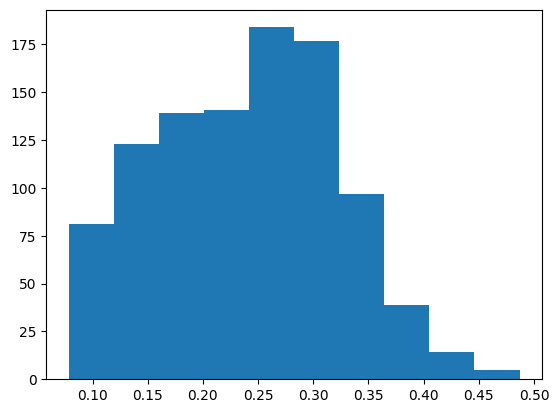

In [41]:
plt.hist(errors)

# ベース色考察(最適解を探す)

In [118]:
n, k, h, t, d, own, target = load_input('in/0000.txt')

def search_color(b):
    trial_cnt = 2
    cnt = 0
    opt_trial = [0, 0, 0, 0]
    opt_score = 1_000_000_000
    opt_color = [0, 0, 0]
    for c1 in range(trial_cnt):
        for c2 in range(trial_cnt):
            for c3 in range(trial_cnt):
                for c4 in range(trial_cnt):
                    trial = [c1, c2, c3, c4]
                    cnt += 1
                    color = mixing_color(trial)
                    # score = 10000*dist(color, target[0]) + d*(sum(trial)-1)
                    score = 10000*dist(color, b)
                    if score < opt_score:
                        # print(f'trial cnt: {cnt}, trial: {trial}, color: {color}, e: {dist(color, target[0])}, score: {round(score)}')
                        opt_score = score
                        opt_trial = trial
                        opt_color = color
    print(f'target: {b}, color: {color}, opt score: {opt_score}, trial: {opt_trial}, cnt: {cnt}')
    return opt_score

search_color(target[0])

K=4, T=60887, D=3822
target: (0.44983, 0.33494, 0.51708), color: (0.4035175, 0.2656975, 0.5073), opt score: 77.44771713155188, trial: [1, 1, 0, 1], cnt: 16


77.44771713155188

In [119]:
def search_one_color(b):
    opt_k = 0
    opt_e = 100
    for k, a in enumerate(own):
        e = dist(a, b)
        if e < opt_e:
            opt_e = e
            opt_k = k
    print(f'target: {b}, color: {own[k]}, opt e: {opt_e*10000}')
    return opt_e*10000

search_one_color(target[0])

target: (0.44983, 0.33494, 0.51708), color: (0.65334, 0.67404, 0.51617), opt e: 3433.038316127567


3433.038316127567

In [120]:
one_score = 1
base_score = 1
for (i, b) in enumerate(target):
    one_score += search_one_color(b)
    base_score += search_color(b)
print(f'one_score: {one_score}')
print(f'base_score: {base_score}')

target: (0.44983, 0.33494, 0.51708), color: (0.65334, 0.67404, 0.51617), opt e: 3433.038316127567
target: (0.44983, 0.33494, 0.51708), color: (0.4035175, 0.2656975, 0.5073), opt score: 77.44771713155188, trial: [1, 1, 0, 1], cnt: 16
target: (0.46831, 0.36471, 0.48477), color: (0.65334, 0.67404, 0.51617), opt e: 3618.108757348237
target: (0.46831, 0.36471, 0.48477), color: (0.4035175, 0.2656975, 0.5073), opt score: 270.25161424124735, trial: [0, 0, 1, 1], cnt: 16
target: (0.50643, 0.31952, 0.31758), color: (0.65334, 0.67404, 0.51617), opt e: 2146.863882503965
target: (0.50643, 0.31952, 0.31758), color: (0.4035175, 0.2656975, 0.5073), opt score: 673.5170813638576, trial: [0, 1, 1, 1], cnt: 16
target: (0.34193, 0.20682, 0.60385), color: (0.65334, 0.67404, 0.51617), opt e: 2063.485384004452
target: (0.34193, 0.20682, 0.60385), color: (0.4035175, 0.2656975, 0.5073), opt score: 787.5801095056227, trial: [1, 0, 1, 1], cnt: 16
target: (0.44749, 0.24562, 0.32353), color: (0.65334, 0.67404, 0.51

## 係数による違い確認

In [69]:
trials = [
    [1,0,0,0], [0,1,0,0], [0,0,1,0], [0,0,0,1],
    [1,1,0,0], [1,0,1,0], [1,0,0,1], [0,1,1,0], [0,1,0,1], [0,0,1,1],
    [0,1,1,1], [1,0,1,1], [1,1,0,1], [1,1,1,0],
    [1,1,1,1],
]
b = target[0]
for trial in trials:
    color = mixing_color(trial)
    score = 10000*dist(color, b) + d*(sum(trial)-1)
    score_e = 10000*dist(color, b)
    print(f'trial: {trial}, score: {score}, score_e: {score_e}')

trial: [1, 0, 0, 0], score: 5202.222973883377, score_e: 5202.222973883377
trial: [0, 1, 0, 0], score: 4154.810990887551, score_e: 4154.810990887551
trial: [0, 0, 1, 0], score: 3433.038316127567, score_e: 3433.038316127567
trial: [0, 0, 0, 1], score: 3954.81931572101, score_e: 3954.81931572101
trial: [1, 1, 0, 0], score: 5758.218966181254, score_e: 1936.218966181253
trial: [1, 0, 1, 0], score: 7731.484401746604, score_e: 3909.484401746604
trial: [1, 0, 0, 1], score: 5801.684387093055, score_e: 1979.6843870930547
trial: [0, 1, 1, 0], score: 6702.665734253109, score_e: 2880.665734253109
trial: [0, 1, 0, 1], score: 6530.679603146153, score_e: 2708.679603146152
trial: [0, 0, 1, 1], score: 4142.35652794972, score_e: 320.35652794972003
trial: [0, 1, 1, 1], score: 9068.485560552377, score_e: 1424.4855605523778
trial: [1, 0, 1, 1], score: 9233.336538377642, score_e: 1589.336538377642
trial: [1, 1, 0, 1], score: 7721.447717131552, score_e: 77.44771713155188
trial: [1, 1, 1, 0], score: 10075.5897

score: 4142.35652794972, score_e: 270.25161424124735, trial: [0, 0, 1, 1]
score: 7721.447717131552, score_e: 415.10803680755464, trial: [1, 1, 0, 1]
score: 9068.485560552377, score_e: 1154.7794387770427, trial: [0, 1, 1, 1]
score: 12304.75025260801, score_e: 1204.5390866426878, trial: [1, 1, 1, 1]
score: 9233.336538377642, score_e: 2049.013383449596, trial: [1, 0, 1, 1]
score: 6530.679603146153, score_e: 2246.8043534095264, trial: [0, 1, 0, 1]
score: 5801.684387093055, score_e: 2276.5100576320774, trial: [1, 0, 0, 1]
score: 5758.218966181254, score_e: 2296.3800001306404, trial: [1, 1, 0, 0]
score: 10075.589755694822, score_e: 2785.5233356289323, trial: [1, 1, 1, 0]
score: 6702.665734253109, score_e: 2920.567094332879, trial: [0, 1, 1, 0]


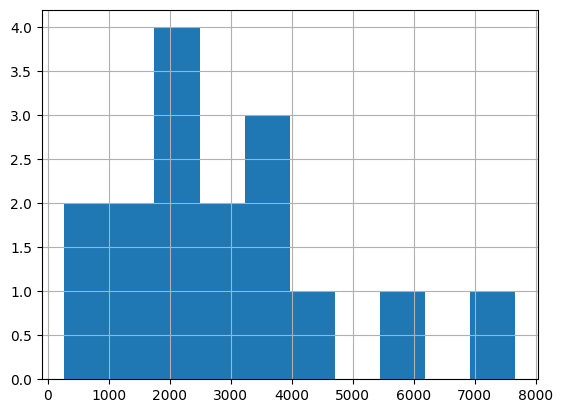

target: (0.46831, 0.36471, 0.48477), color: (0.65334, 0.67404, 0.51617), opt e: 3618.108757348237
10%: 784.9437377922986


count      16.000000
mean     2913.672614
std      1927.546140
min       270.251614
25%      1837.894809
50%      2540.951668
75%      3809.606068
max      7663.743166
dtype: float64

In [99]:
b = target[1]

trial_cnt = 2
cnt = 0
priority_queue = []
for c1 in range(trial_cnt):
    for c2 in range(trial_cnt):
        for c3 in range(trial_cnt):
            for c4 in range(trial_cnt):
                trial = [c1, c2, c3, c4]
                cnt += 1
                color = mixing_color(trial)
                score = 10000*dist(color, target[0]) + d*(sum(trial)-1)
                score_e = 10000*dist(color, b)
                heapq.heappush(priority_queue, (score_e, score, trial))

scores = []
cnt = 0
while priority_queue:
    cnt += 1
    score_e, score, trial = heapq.heappop(priority_queue)
    if cnt <= 10:
        print(f'score: {score}, score_e: {score_e}, trial: {trial}')
    scores.append(score_e)

score_df = pd.Series(scores)
score_df.hist()
plt.show()
search_one_color(b)
print('10%:', score_df.quantile(0.1))
score_df.describe()

## 同じ係数の数

In [105]:
n, k, h, t, d, own, target = load_input('in/0000.txt')

def search_color(b):
    trial_cnt = 2
    cnt = 0
    opt_trial = [0, 0, 0, 0]
    opt_score = 1_000_000_000
    opt_color = [0, 0, 0]
    for c1 in range(trial_cnt):
        for c2 in range(trial_cnt):
            for c3 in range(trial_cnt):
                for c4 in range(trial_cnt):
                    trial = [c1, c2, c3, c4]
                    cnt += 1
                    color = mixing_color(trial)
                    # score = 10000*dist(color, target[0]) + d*(sum(trial)-1)
                    score = 10000*dist(color, b)
                    if score < opt_score:
                        # print(f'trial cnt: {cnt}, trial: {trial}, color: {color}, e: {dist(color, target[0])}, score: {round(score)}')
                        opt_score = score
                        opt_trial = trial
                        opt_color = color
    return opt_trial

trail_dict = {}

for b in target:
    trial = search_color(b)
    trial = str(trial)
    trail_dict[trial] = trail_dict.get(trial, 0) + 1
trail_dict

K=4, T=60887, D=3822


{'[1, 1, 0, 1]': 60,
 '[0, 0, 1, 1]': 149,
 '[0, 1, 1, 1]': 106,
 '[1, 0, 1, 1]': 120,
 '[1, 1, 1, 1]': 114,
 '[1, 1, 0, 0]': 124,
 '[1, 0, 1, 0]': 72,
 '[1, 0, 0, 0]': 9,
 '[1, 1, 1, 0]': 85,
 '[0, 0, 0, 1]': 17,
 '[0, 1, 1, 0]': 75,
 '[1, 0, 0, 1]': 20,
 '[0, 1, 0, 0]': 16,
 '[0, 0, 1, 0]': 12,
 '[0, 1, 0, 1]': 21}